In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from torch.nn.utils.rnn import pad_sequence
import re
import string
from collections import Counter
import gc
import numpy as np
from opacus import PrivacyEngine
from opacus.layers import DPLSTM

In [2]:
imdb = load_dataset("imdb")
cornellmovie = load_dataset("cornell-movie-review-data/rotten_tomatoes")

max_imdb_contribution = len(imdb["train"])
max_cornellmovie_contribution = len(cornellmovie["train"])

total_if_imdb_maxed = int(len(imdb["train"]) / 0.04)
total_if_cornellmovie_maxed = int(len(cornellmovie["train"]) / 0.96)
total_desired_size = min(total_if_imdb_maxed, total_if_cornellmovie_maxed)
imdb_size = int(0.04 * total_desired_size)
cornellmovie_size = int(0.96 * total_desired_size)

np.random.seed(42)
imdb_indices = np.random.choice(len(imdb["train"]), size=imdb_size, replace=False)
cornellmovie_indices = np.random.choice(len(cornellmovie["train"]), size=cornellmovie_size, replace=False)

imdb_subset = imdb["train"].select(imdb_indices)
cornellmovie_subset = cornellmovie["train"].select(cornellmovie_indices)

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return clean_text(text).split()

counter = Counter()
for example in imdb["train"]:
    counter.update(tokenize(example["text"]))

min_freq = 3
vocab = {"<pad>": 0, "<unk>": 1}
for word, freq in counter.items():
    if freq >= min_freq:
        vocab[word] = len(vocab)
inv_vocab = {v: k for k, v in vocab.items()}
PAD_IDX = vocab["<pad>"]
UNK_IDX = vocab["<unk>"]

def text_pipeline(text, max_len=256):
    tokens = tokenize(text)
    ids = [vocab.get(token, UNK_IDX) for token in tokens[:max_len]]
    return torch.tensor(ids, dtype=torch.long)

In [4]:
class TextDataset(Dataset):
    def __init__(self, hf_dataset, label_transform, text_field, max_len=256):
        self.data = hf_dataset
        self.label_transform = label_transform
        self.max_len = max_len
        self.text_field = text_field

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokens = text_pipeline(item[self.text_field], max_len=self.max_len)
        label = torch.tensor(self.label_transform(item["label"]), dtype=torch.long)
        return tokens, label

def collate_batch(batch):
    texts, labels = zip(*batch)
    padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return padded, torch.stack(labels)

In [5]:
train_loader_public = DataLoader(
    TextDataset(imdb_subset, label_transform=lambda x: x, text_field="text"),
    batch_size=64, shuffle=True, collate_fn=collate_batch
)

train_loader_private = DataLoader(
    TextDataset(cornellmovie_subset, label_transform=lambda x: x, text_field="text"),
    batch_size=64, shuffle=True, collate_fn=collate_batch
)

test_loader = DataLoader(
    TextDataset(cornellmovie["test"], label_transform=lambda x: x, text_field="text"),
    batch_size=64, shuffle=False, collate_fn=collate_batch
)

In [6]:
class Model(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = DPLSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(len(vocab), num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
privacy_engine = PrivacyEngine()
gc.collect()

/opt/anaconda3/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


130

In [8]:
epochs_1 = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs_1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_public:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/{epochs_1}]')
    print("Training loss", (running_loss / total))  
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss_eval / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

Epoch [1/5]
Training loss 0.6943183897246777
Training accuracy 48.45070422535211 %
Testing loss 0.6926128816202032
Testing accuracy 50.37523452157598 %
Epoch [2/5]
Training loss 0.6758827456286256
Training accuracy 58.87323943661972 %
Testing loss 0.6930858061192854
Testing accuracy 50.093808630393994 %
Epoch [3/5]
Training loss 0.6605676009621418
Training accuracy 62.25352112676056 %
Testing loss 0.6949655702145418
Testing accuracy 50.0 %
Epoch [4/5]
Training loss 0.646620593944066
Training accuracy 63.098591549295776 %
Testing loss 0.6970853722788827
Testing accuracy 50.0 %
Epoch [5/5]
Training loss 0.6303364009924338
Training accuracy 63.38028169014085 %
Testing loss 0.6987679097486929
Testing accuracy 50.093808630393994 %


In [9]:
epochs_2 = 10
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
target_delta = 1e-5
model, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader_private,
    epochs=10,
    target_epsilon=3,
    target_delta=target_delta,
    max_grad_norm=0.1,
)
for epoch in range(epochs_2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_private:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()

    epsilon = privacy_engine.get_epsilon(delta=target_delta)
    print(f"Privacy Budget (epsilon, delta): ({epsilon:.2f}, {target_delta})")

    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss_eval / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()
    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            eval_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")

/opt/anaconda3/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/10]
Training loss 0.6993820933137894
Training accuracy 49.81114258734655 %
Privacy Budget (epsilon, delta): (1.49, 1e-05)
Testing loss 0.6944332581300002
Testing accuracy 49.812382739212005 %
Epoch [2/10]
Training loss 0.6970807781380055
Training accuracy 50.38077106139934 %
Privacy Budget (epsilon, delta): (1.76, 1e-05)
Testing loss 0.6943631270589345
Testing accuracy 49.906191369606006 %
Epoch [3/10]
Training loss 0.6989169624759447
Training accuracy 50.93009820912767 %
Privacy Budget (epsilon, delta): (1.97, 1e-05)
Testing loss 0.709596010354849
Testing accuracy 50.093808630393994 %
Epoch [4/10]
Training loss 0.7089647855783734
Training accuracy 50.070093457943926 %
Privacy Budget (epsilon, delta): (2.15, 1e-05)
Testing loss 0.7104136547943888
Testing accuracy 50.187617260787995 %
Epoch [5/10]
Training loss 0.7041382217822668
Training accuracy 49.73687288036487 %
Privacy Budget (epsilon, delta): (2.31, 1e-05)
Testing loss 0.7014306980494487
Testing accuracy 50.1876172607879

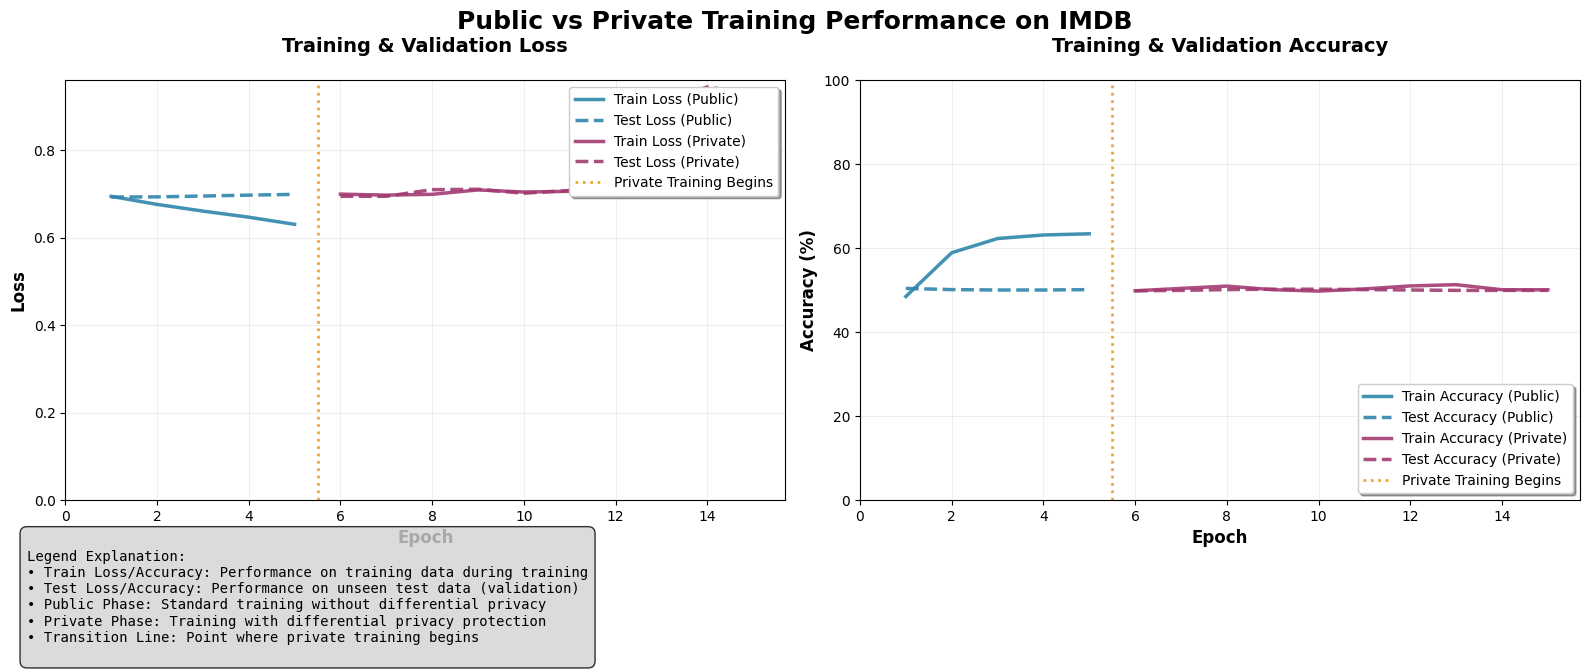

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Combine loss and accuracy for plotting
full_train_losses = train_losses + train_losses_2
full_test_losses = test_losses + test_losses_2
full_train_accuracies = train_accuracies + train_accuracies_2
full_test_accuracies = test_accuracies + test_accuracies_2

# Create epoch ranges
public_epochs = list(range(1, epochs_1 + 1))
private_epochs = list(range(epochs_1 + 1, epochs_1 + epochs_2 + 1))

# Set up the figure with improved styling
plt.rcParams.update({'font.size': 10})  # Set default font size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define colors for consistency
public_color = '#2E86AB'    # Blue
private_color = '#A23B72'   # Red/Purple
transition_color = '#F18F01' # Orange

# --- Loss Plot ---
ax1.plot(public_epochs, train_losses, color=public_color, linewidth=2.5, 
         label='Train Loss (Public)', alpha=0.9)
ax1.plot(public_epochs, test_losses, color=public_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Public)', alpha=0.9)

ax1.plot(private_epochs, train_losses_2, color=private_color, linewidth=2.5, 
         label='Train Loss (Private)', alpha=0.9)
ax1.plot(private_epochs, test_losses_2, color=private_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Private)', alpha=0.9)

# Add transition line with better styling
ax1.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# --- Accuracy Plot ---
# Note: Your accuracy values are already in percentage (0-100), so don't multiply by 100
ax2.plot(public_epochs, train_accuracies, color=public_color, 
         linewidth=2.5, label='Train Accuracy (Public)', alpha=0.9)
ax2.plot(public_epochs, test_accuracies, color=public_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Public)', alpha=0.9)

ax2.plot(private_epochs, train_accuracies_2, color=private_color, 
         linewidth=2.5, label='Train Accuracy (Private)', alpha=0.9)
ax2.plot(private_epochs, test_accuracies_2, color=private_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Private)', alpha=0.9)

# Add transition line
ax2.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)

# Add overall title with more spacing
fig.suptitle('Public vs Private Training Performance on IMDB', 
             fontsize=18, fontweight='bold', y=0.95)

# Improve layout with space for glossary
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)  # More space for the glossary at bottom

# Add glossary/legend explanation
glossary_text = """
Legend Explanation:
• Train Loss/Accuracy: Performance on training data during training
• Test Loss/Accuracy: Performance on unseen test data (validation)
• Public Phase: Standard training without differential privacy
• Private Phase: Training with differential privacy protection
• Transition Line: Point where private training begins
"""

# Add glossary as text box
props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
fig.text(0.02, 0.02, glossary_text, fontsize=10, verticalalignment='bottom',
         bbox=props, family='monospace')

plt.show()

# Optional: Save the figure in high quality
# plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')